In [2]:
import grewpy
from grewpy import Corpus, CorpusDraft, Request
from collections import Counter
import sys
sys.path.insert(1, "/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/tod")

import tod.corpus
import tod.outliers
import tod.clustering
import tod.plotting
import tod.dimension_reduction_classic

# treebank_path = "/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/data/input/Universal_Dependencies/ud-treebanks-v2.15/UD_French-GSD"

# treebank_path = "/Users/madalina/Downloads/bUD_English-GUM"
# treebank_path = "/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/data/input/Universal_Dependencies/ud-treebanks-v2.15/UD_Wolof-WTB"
# treebank_path = "/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/data/input/Universal_Dependencies/ud-treebanks-v2.15/UD_Chinese-GSD"
treebank_path = "/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/data/input/Universal_Dependencies/ud-treebanks-v2.15/UD_Japanese-GSD"
grew_pattern = "pattern{X[upos<>PUNCT]}"
patterns_text_file = "/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/scripts/3. probability_matrix/patterns_all_nodes.txt"
analysed_category = "all_nodes"

corpus = tod.corpus.Corpus(
    treebank_path=treebank_path,
    grew_pattern=grew_pattern,
    patterns_text_file=patterns_text_file,
    use_sud=False,
    matrix_type="coverage",
    # excluded_feature_patterns=[r"CxnElt=", r"Cxn=", r"own", r"Gender"] # for french
        # excluded_feature_patterns=[r"CxnElt=", r"Cxn=", r"XML=", r"PDTB=", r"SplitAnte=", r"MSeg=", r"Entity=", r"Discourse=", r"Bridge=", r"own", r"Degree=Pos"] # for english
    # excluded_feature_patterns = [r"own", r"Translit"] for chinese
    excluded_feature_patterns=[r"UnidicInfo=", r"LUWPOS=", r"PrevUDLemma", r"own"] # for japanese
)

connected to port: 49769


In [3]:
corpus._feature2idx

{'node:X:child:BunsetuBILabel=B': 0,
 'node:X:child:BunsetuBILabel=I': 1,
 'node:X:child:BunsetuPositionType=CONT': 2,
 'node:X:child:BunsetuPositionType=FUNC': 3,
 'node:X:child:BunsetuPositionType=SEM_HEAD': 4,
 'node:X:child:BunsetuPositionType=SYN_HEAD': 5,
 'node:X:child:LUWBILabel=B': 6,
 'node:X:child:LUWBILabel=I': 7,
 'node:X:child:Polarity=Neg': 8,
 'node:X:child:rel_shallow=acl': 9,
 'node:X:child:rel_shallow=advcl': 10,
 'node:X:child:rel_shallow=advmod': 11,
 'node:X:child:rel_shallow=amod': 12,
 'node:X:child:rel_shallow=aux': 13,
 'node:X:child:rel_shallow=case': 14,
 'node:X:child:rel_shallow=cc': 15,
 'node:X:child:rel_shallow=ccomp': 16,
 'node:X:child:rel_shallow=compound': 17,
 'node:X:child:rel_shallow=cop': 18,
 'node:X:child:rel_shallow=csubj': 19,
 'node:X:child:rel_shallow=csubj:outer': 20,
 'node:X:child:rel_shallow=dep': 21,
 'node:X:child:rel_shallow=det': 22,
 'node:X:child:rel_shallow=discourse': 23,
 'node:X:child:rel_shallow=mark': 24,
 'node:X:child:rel

In [4]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(corpus.feature_matrix)

In [5]:
import numpy as np
results = []
lex_units_with_different_neighbours = set()
for idx, lex_unit in corpus._idx2lexunit.items():
    current_category = lex_unit[1]
    closest_neighbours = np.argsort(similarity_matrix[idx])[:-21:-1]
    closest_neighbours = [i for i in closest_neighbours if i != idx][:20]
    for neighbour_idx in closest_neighbours:
        neighbour_category = corpus._idx2lexunit[neighbour_idx][1]
        if neighbour_category != current_category and similarity_matrix[idx][neighbour_idx] > 0.5:
            diff = np.abs(corpus.feature_matrix[idx] - corpus.feature_matrix[neighbour_idx])
            closest_features_idx= np.argsort(diff)[:-6:-1]
            closest_features = [corpus._idx2feature[i] for i in closest_features_idx]
                
            results.append({
                "lex_unit": lex_unit,
                "neighbour_lex_unit": corpus._idx2lexunit[neighbour_idx],
                "distance": similarity_matrix[idx][neighbour_idx],
                "closest_features": closest_features,
                
            })
            lex_units_with_different_neighbours.add(lex_unit)
    

for r in results:
    print(r)   

{'lex_unit': ('&', 'SYM'), 'neighbour_lex_unit': ('春秋', 'NOUN'), 'distance': 0.9798015265550484, 'closest_features': ['node:X:prev:upos=NOUN', 'node:X:prev:upos=PROPN', 'node:X:prev:BunsetuBILabel=B', 'node:X:parent:upos=NOUN', 'node:X:next:upos=NOUN']}
{'lex_unit': ('&', 'SYM'), 'neighbour_lex_unit': ('執行', 'NOUN'), 'distance': 0.9792532008400597, 'closest_features': ['node:X:prev:upos=PROPN', 'node:X:next:upos=NOUN', 'node:X:prev:BunsetuPositionType=CONT', 'node:X:next:upos=PROPN', 'node:X:prev:BunsetuBILabel=B']}
{'lex_unit': ('&', 'SYM'), 'neighbour_lex_unit': ('五', 'NUM'), 'distance': 0.9750759861347755, 'closest_features': ['node:X:prev:upos=PROPN', 'node:X:prev:upos=NOUN', 'node:X:next:upos=NOUN', 'node:X:next:upos=PROPN', 'node:X:prev:BunsetuBILabel=I']}
{'lex_unit': ('&', 'SYM'), 'neighbour_lex_unit': ('40', 'NUM'), 'distance': 0.9684356084786917, 'closest_features': ['node:X:prev:BunsetuPositionType=CONT', 'node:X:prev:BunsetuBILabel=B', 'node:X:next:upos=PROPN', 'node:X:pare

In [6]:
len(lex_units_with_different_neighbours)

1201

In [7]:
category_counts = {}
for idx, lex_unit in corpus._idx2lexunit.items():
    category = lex_unit[1]
    if category not in category_counts:
        category_counts[category] = {"total": 0, "with_different_neighbour": 0}
    category_counts[category]["total"] += 1
    if lex_unit in lex_units_with_different_neighbours:
        category_counts[category]["with_different_neighbour"] += 1

for category, counts in category_counts.items():
    total = counts["total"]
    with_diff = counts["with_different_neighbour"]
    percentage = (with_diff / total) * 100 if total > 0 else 0
    print(f"Category: {category}, Total: {total}, With Different Neighbour: {with_diff}, Percentage: {percentage:.2f}%")

Category: NOUN, Total: 1845, With Different Neighbour: 595, Percentage: 32.25%
Category: SYM, Total: 11, With Different Neighbour: 11, Percentage: 100.00%
Category: NUM, Total: 105, With Different Neighbour: 93, Percentage: 88.57%
Category: PROPN, Total: 109, With Different Neighbour: 109, Percentage: 100.00%
Category: PRON, Total: 21, With Different Neighbour: 21, Percentage: 100.00%
Category: ADP, Total: 30, With Different Neighbour: 16, Percentage: 53.33%
Category: PART, Total: 17, With Different Neighbour: 17, Percentage: 100.00%
Category: SCONJ, Total: 19, With Different Neighbour: 19, Percentage: 100.00%
Category: ADV, Total: 98, With Different Neighbour: 75, Percentage: 76.53%
Category: AUX, Total: 31, With Different Neighbour: 31, Percentage: 100.00%
Category: CCONJ, Total: 13, With Different Neighbour: 13, Percentage: 100.00%
Category: VERB, Total: 494, With Different Neighbour: 80, Percentage: 16.19%
Category: ADJ, Total: 120, With Different Neighbour: 116, Percentage: 96.67%

In [8]:
from scipy.stats import entropy
scores = {}
for idx, lex_unit in corpus._idx2lexunit.items():
    current_category = lex_unit[1]
    closest_neighbours = np.argsort(similarity_matrix[idx])[:-21:-1]
    closest_neighbours = [i for i in closest_neighbours if i != idx][:20]
    purity_top, purity_bottom = 0, 0
    category_weights = {}
    for neighbour_idx in closest_neighbours:
        neighbour_category = corpus._idx2lexunit[neighbour_idx][1]
        distance_to_neighbour = similarity_matrix[idx][neighbour_idx]
        purity_bottom += distance_to_neighbour # the sum of all the inverse weights
        if neighbour_category in category_weights:
            category_weights[neighbour_category] += distance_to_neighbour
        else:
            category_weights[neighbour_category] = distance_to_neighbour

        if neighbour_category == current_category:
            purity_top += distance_to_neighbour

    purity_score = purity_top / purity_bottom

    probabilities = [v / purity_bottom for v in category_weights.values()]
    entropy_score = entropy(probabilities)
    
    scores[lex_unit] = {}
    scores[lex_unit]["purity"] = purity_score
    scores[lex_unit]["entropy"] = entropy_score

    rival_cat = None
    rival_weight = 0

    for cat, w in category_weights.items():
        if cat != current_category and w > rival_weight:
            rival_weight = w
            rival_cat = cat

    scores[lex_unit]["rival_category"] = rival_cat
    scores[lex_unit]["rival_weight_ratio"] = rival_weight / purity_bottom if purity_bottom > 0 else 0
    

In [9]:
scores

{('%', 'NOUN'): {'purity': 1.0,
  'entropy': 0.0,
  'rival_category': None,
  'rival_weight_ratio': 0.0},
 ('&', 'SYM'): {'purity': 0.10575659139754624,
  'entropy': 1.0935934536443537,
  'rival_category': 'NOUN',
  'rival_weight_ratio': 0.526025049028208},
 ('-', 'SYM'): {'purity': 0.37165596638837645,
  'entropy': 1.0142426279765093,
  'rival_category': 'NOUN',
  'rival_weight_ratio': 0.47027895170769923},
 ('/', 'SYM'): {'purity': 0.1590768689743601,
  'entropy': 1.0304697849914135,
  'rival_category': 'NUM',
  'rival_weight_ratio': 0.6301186993457969},
 ('0', 'NUM'): {'purity': 0.15756063484199537,
  'entropy': 0.4356026265166331,
  'rival_category': 'NOUN',
  'rival_weight_ratio': 0.8424393651580045},
 ('000', 'NUM'): {'purity': 0.6309279839526741,
  'entropy': 0.8798204876364635,
  'rival_category': 'NOUN',
  'rival_weight_ratio': 0.2630134079739636},
 ('06', 'NUM'): {'purity': 0.6316419455106649,
  'entropy': 0.809368352202709,
  'rival_category': 'NOUN',
  'rival_weight_ratio':

In [10]:
import plotly.express as px
import pandas as pd

# Convert your 'scores' dictionary to a DataFrame
df = pd.DataFrame.from_dict(scores, orient='index')

# # Assuming lex_unit was a tuple (word, pos)
# df['word'] = df.index.apply(lambda x: x[0])
# df['category'] = df['index'].apply(lambda x: x[1])

# # Calculate medians for the dashed lines
med_p = df['purity'].median()
med_e = df['entropy'].median()

fig = px.scatter(
    df, x="purity", y="entropy",  
    hover_name=list(df.index),
    hover_data={
        "purity": True,
        "entropy": True,
        "rival_category": True,
        "rival_weight_ratio": True
    },
    title="Polycategoriality Analysis: Purity vs Entropy",
    labels={"purity": "Purity (Categorical Homogeneity)", "entropy": "Entropy (Categorical Competition)", "rival_category": "Other category around", "rival_weight_ratio": "Its weight"},
    # template="plotly_dark" # Or "plotly_white"
)

# Add the "Crosshair" at the medians

fig.add_vline(x=med_p, line_dash="dash", line_color="gray", opacity=0.5)
fig.add_hline(y=med_e, line_dash="dash", line_color="gray", opacity=0.5)

fig.show()

/opt/homebrew/lib/python3.11/site-packages/kaleido/__init__.py:14: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Identify the 'Rival' for each unit
matrix_data = []

for lex_unit, stats in scores.items():
    current_cat = lex_unit[1]
    
    # We only care about units that have some level of 'pull' from others
    if stats['rival_category'] is not None:
        
       matrix_data.append(
           {
               "Original": current_cat,
               "Rival": stats['rival_category']
           }
       )
df_transitions = pd.DataFrame(matrix_data)
transition_matrix = pd.crosstab(
    df_transitions['Original'], 
    df_transitions['Rival'], 
    normalize='index'
)


In [15]:
# Instead of picking one 'rival_category' per word:
all_overlaps = []

all_overlaps = []

for lex_unit, stats in scores.items():
    current_cat = lex_unit[1]
    # Recalculate weights for THIS lex_unit
    idx = corpus._lexunit2idx[lex_unit]
    closest_neighbours = np.argsort(similarity_matrix[idx])[:-21:-1]
    closest_neighbours = [i for i in closest_neighbours if i != idx][:20]
    
    purity_bottom = 0
    category_weights = {}
    
    for neighbour_idx in closest_neighbours:
        neighbour_category = corpus._idx2lexunit[neighbour_idx][1]
        distance_to_neighbour = similarity_matrix[idx][neighbour_idx]
        purity_bottom += distance_to_neighbour
        
        if neighbour_category in category_weights:
            category_weights[neighbour_category] += distance_to_neighbour
        else:
            category_weights[neighbour_category] = distance_to_neighbour
    
    for rival_cat, weight in category_weights.items():
        if rival_cat != current_cat:
            all_overlaps.append({
                "Original": current_cat,
                "Rival": rival_cat,
                "Weight": weight / purity_bottom if purity_bottom > 0 else 0
            })

df_overlaps = pd.DataFrame(all_overlaps)
# Group by Original and Rival, then sum the weights and normalize
transition_matrix = df_overlaps.groupby(['Original', 'Rival'])['Weight'].sum().unstack(fill_value=0)
transition_matrix = transition_matrix.div(transition_matrix.sum(axis=1), axis=0)

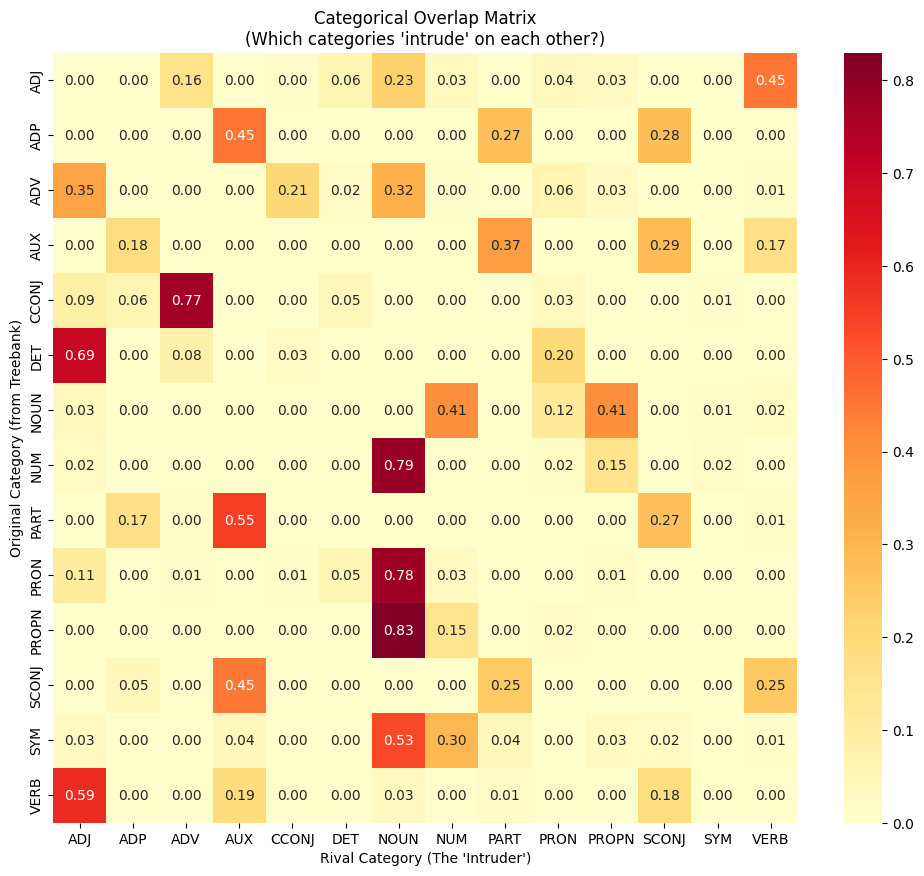

In [16]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    transition_matrix, 
    annot=True,      # Show the numbers in the cells
    cmap="YlOrRd",   # Color gradient: Yellow (low) to Red (high)
    fmt=".2f"        # Format to 2 decimal places
)

plt.title("Categorical Overlap Matrix\n(Which categories 'intrude' on each other?)")
plt.ylabel("Original Category (from Treebank)")
plt.xlabel("Rival Category (The 'Intruder')")
plt.show()

In [62]:
def get_top_bridge_words(scores_dict, original_cat, rival_cat, top_n=100):
    """Finds the words from original_cat most pulled toward rival_cat."""
    matches = []
    
    for (word, o_cat), data in scores_dict.items():
        if o_cat == original_cat and data["rival_category"] == rival_cat:
            matches.append((word, data["purity"], data["entropy"]))
            
    # Sort by lowest purity (the ones most 'pulled' away)
    matches.sort(key=lambda x: x[1])
    
    return matches[:top_n]

# Example: Who are the Verbs that look like Adjectives?
category_to_compare_1 = "ADJ"
category_to_compare_2 = "VERB"
bridge_verbs = get_top_bridge_words(scores, category_to_compare_1, category_to_compare_2)
print(f"Top {category_to_compare_1} -> {category_to_compare_2} bridge words: ")
print(f"Word \t Purity \t Entropy")
for v in bridge_verbs:
    print(v)

Top ADJ -> VERB bridge words: 
Word 	 Purity 	 Entropy
('有名', 0.05292071034398877, 0.2070269110103496)
('ぴったり', 0.10415713145162324, 0.3341222733846818)
('近い', 0.15730008228479014, 0.43516555657514516)
('必要', 0.15755793366204174, 0.4355980979843964)
('最高', 0.15766083456786442, 1.1793323275414678)
('同様', 0.1577040732935727, 0.4358430223527441)
('不明', 0.1579330986218484, 0.43622653656702076)
('美味しい', 0.15807471278386942, 0.4364634791031138)
('便利', 0.21084304249171684, 0.5150714991248115)
('豊富', 0.2115057022879364, 0.5159447929388878)
('多い', 0.21201065024141577, 0.5166084764319653)
('安い', 0.2636629412263915, 0.5768534759778879)
('嬉しい', 0.26530345899405267, 0.5785313927003024)
('残念', 0.26834430602165527, 0.5816050863880122)
('満足', 0.3186066321844495, 0.9937755885017212)
('無い', 0.3699721200986598, 0.6589408408635002)
('辛い', 0.42317289220012594, 0.6812954760934166)
('可能', 0.424040860459129, 0.9546361386511493)
('酷い', 0.4760551378498518, 0.6920000289937882)
('良い', 0.5273592927728669, 0.691649

In [60]:
def get_pulling_features(lex_unit, rival_category, corpus, similarity_matrix, top_k_features=20):
    lex_unit_vector = corpus.feature_matrix[corpus._lexunit2idx[lex_unit]]
    closest_neighbours_indices = np.argsort(similarity_matrix[idx])[::-1]
    rival_cat_neighbours_idx = []
    for i in closest_neighbours_indices:
        if i != corpus._lexunit2idx[lex_unit] and corpus._idx2lexunit[i][1] == rival_category:
            rival_cat_neighbours_idx.append(i)
    
    rival_centroid = np.median(corpus.feature_matrix[rival_cat_neighbours_idx[:20]], axis=0)
    
    feat_idx_to_compare = []
    for feature_value_idx in range(len(rival_centroid)):
        if rival_centroid[feature_value_idx] > 0:
            feat_idx_to_compare.append(feature_value_idx)

    diffs = {}
    for f in feat_idx_to_compare:
        diff = abs(lex_unit_vector[f] - rival_centroid[f])
        diffs[f] = diff

    for f_idx, diff in diffs.items():
        print(corpus.idx2feature(idx), diff)
    # feature_differences = np.abs(lex_unit_vector - rival_centroid)
    
    # global_variance = np.var(corpus.feature_matrix, axis=0)

    # bridge_score = global_variance / (feature_differences + 1e-6)
    # top_feature_indices = np.argsort(bridge_score)[::-1][:top_k_features]

    # most_similar_features = {}
    # for i in range(len(feature_differences)):
    #     if feature_differences[i] > 0:
    #         most_similar_features[corpus._idx2feature[i]] = feature_differences[i]
    
    # sorted_most_similar_features = {k: v for k, v in sorted(most_similar_features.items(), key = lambda item: item[1])}
    # print(sorted_most_similar_features)
    # # We rank by (Value / (Difference + epsilon)) 
    # # This prioritizes high-frequency features that match the rival perfectly
    # relevance_score = lex_unit_vector / (feature_differences + 1e-6)
    # top_feature_indices = np.argsort(relevance_score)[::-1][:top_k_features]
    # results = []
    # for f_idx in top_feature_indices:
    #     print(corpus._idx2feature[f_idx])
    #     # results.append(
    #     #     {
    #     #     "feature": corpus._idx2feature[f_idx],
    #     #     "unit_value": lex_unit_vector[f_idx],
    #     #     "rival_avg": rival_centroid[f_idx],
    #     #     "diff": feature_differences[f_idx]
    #     #     }
    #     # )


In [119]:
get_pulling_features(('willing', 'ADJ'), "VERB", corpus, similarity_matrix)

UnboundLocalError: cannot access local variable 'idx' where it is not associated with a value

In [61]:
result = get_pulling_features(('有名', 'ADJ'), "VERB", corpus, similarity_matrix)
print(result)

KeyError: 2917